# nuScenes 座標変換 デモノートブック

`autonomous_driving/VAD/nuscenes_dataset.md` の補足。  
4×4 同次変換行列を一歩ずつ手で追い、global → ego → LiDAR の変換チェーンを可視化する。

**目次**
1. 同次変換行列の基礎
2. nuScenes 座標チェーン（global → ego → LiDAR）
3. 具体的な数値で変換を追う
4. `gt_ego_his_trajs` の座標変換ステップを可視化
5. 各座標系を並べて比較

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['figure.dpi'] = 120
np.set_printoptions(precision=4, suppress=True)
print("imports OK")

imports OK


---
## 1. 同次変換行列の基礎

3D の **剛体変換**（回転 + 平行移動）は 4×4 の同次変換行列で表現できる：

$$T = \begin{bmatrix} R & \mathbf{t} \\ \mathbf{0}^\top & 1 \end{bmatrix}$$

- $R$：3×3 回転行列
- $\mathbf{t}$：3×1 平行移動ベクトル

点 $\mathbf{p}$ の変換：$\mathbf{p}' = T \begin{bmatrix} \mathbf{p} \\ 1 \end{bmatrix}$

**逆変換**（座標系 A から B → B から A）：

$$T^{-1} = \begin{bmatrix} R^\top & -R^\top \mathbf{t} \\ \mathbf{0}^\top & 1 \end{bmatrix}$$

**変換の合成**（A→B→C）：$T_{AC} = T_{BC} \cdot T_{AB}$（右から左に掛ける）

In [2]:
def rot_z(yaw: float) -> np.ndarray:
    """Z 軸周りの 4x4 回転行列"""
    c, s = np.cos(yaw), np.sin(yaw)
    return np.array([[c,-s, 0, 0],
                     [s, c, 0, 0],
                     [0, 0, 1, 0],
                     [0, 0, 0, 1]], dtype=float)

def trans(tx, ty, tz=0.0) -> np.ndarray:
    """4x4 平行移動行列"""
    T = np.eye(4)
    T[:3, 3] = [tx, ty, tz]
    return T

def rigid(tx, ty, yaw, tz=0.0) -> np.ndarray:
    """平行移動 × 回転の合成"""
    return trans(tx, ty, tz) @ rot_z(yaw)

def transform_point(T: np.ndarray, p: np.ndarray) -> np.ndarray:
    """4x4 変換行列で 3D 点を変換"""
    ph = np.array([p[0], p[1], p[2], 1.0])
    return (T @ ph)[:3]

# --- 基本的な変換の確認 ---
# 例: 平行移動 (5, 3, 0) + 90° 回転
T_example = rigid(5.0, 3.0, yaw=np.pi/2)
p_orig = np.array([1.0, 0.0, 0.0])   # x 方向に 1m の点
p_transformed = transform_point(T_example, p_orig)

print("変換行列 T (tx=5, ty=3, yaw=90°):")
print(T_example)
print(f"\n元の点:    {p_orig}")
print(f"変換後の点: {p_transformed.round(4)}")
print(f"  → x=1 の点は yaw=90° で y 方向に回転し、さらに (5,3) 平行移動")

# 逆変換の確認
T_inv = np.linalg.inv(T_example)
p_back = transform_point(T_inv, p_transformed)
print(f"\n逆変換後:  {p_back.round(6)}  (元に戻ること確認)")

変換行列 T (tx=5, ty=3, yaw=90°):
[[ 0. -1.  0.  5.]
 [ 1.  0.  0.  3.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0.  1.]]

元の点:    [1. 0. 0.]
変換後の点: [5. 4. 0.]
  → x=1 の点は yaw=90° で y 方向に回転し、さらに (5,3) 平行移動

逆変換後:  [1. 0. 0.]  (元に戻ること確認)


---
## 2. nuScenes の座標チェーン

```
global (world)
  └─ T_global_from_ego   (ego_pose テーブル: 各タイムスタンプの自車位置・姿勢)
       └─ ego
            └─ T_ego_from_sensor  (calibrated_sensor テーブル: センサー取り付け位置)
                 └─ LiDAR (sensor)
```

**関係式**：
$$T_{\text{global←LiDAR}} = T_{\text{global←ego}} \times T_{\text{ego←LiDAR}}$$

**LiDAR グローバル位置**（平行移動成分）：
$$\mathbf{p}_{\text{LiDAR}}^{\text{global}} = T_{\text{global←LiDAR}}[:3, 3]$$

**グローバル点を LiDAR 座標に変換**：
$$T_{\text{LiDAR←global}} = T_{\text{global←LiDAR}}^{-1}$$

In [3]:
# --- 具体的な nuScenes 風パラメータで変換チェーンを追う ---

# ego_pose: 自車がグローバル (30m, 10m) にいて yaw=30° 向いている
ego_tx, ego_ty, ego_yaw = 30.0, 10.0, np.radians(30)
T_global_from_ego = rigid(ego_tx, ego_ty, ego_yaw)

# calibrated_sensor: LiDAR は ego の前方 1.5m, 高さ 1.84m
lidar_tx, lidar_ty, lidar_tz = 1.5, 0.0, 1.84
T_ego_from_lidar = rigid(lidar_tx, lidar_ty, yaw=0.0, tz=lidar_tz)

# --- Step 1: global_from_lidar の計算 ---
T_global_from_lidar = T_global_from_ego @ T_ego_from_lidar
lidar_pos_global = T_global_from_lidar[:3, 3]

print("=" * 55)
print("Step 1: T_global_from_ego")
print(T_global_from_ego)
print(f"\nego 位置 (global): ({ego_tx}, {ego_ty}, 0)  yaw={np.degrees(ego_yaw):.0f}°")

print("\n" + "=" * 55)
print("Step 2: T_ego_from_lidar")
print(T_ego_from_lidar)
print(f"\nLiDAR オフセット (ego 座標): tx={lidar_tx}, tz={lidar_tz}")

print("\n" + "=" * 55)
print("Step 3: T_global_from_lidar = T_global_from_ego @ T_ego_from_lidar")
print(T_global_from_lidar)
print(f"\nLiDAR グローバル位置: {lidar_pos_global.round(4)}")

# --- Step 2: LiDAR 座標系への逆変換 ---
T_lidar_from_global = np.linalg.inv(T_global_from_lidar)

# グローバル座標系に障害物がある: (35, 12, 0)
obstacle_global = np.array([35.0, 12.0, 0.0])
obstacle_lidar  = transform_point(T_lidar_from_global, obstacle_global)

print("\n" + "=" * 55)
print("Step 4: 障害物 global→LiDAR 変換")
print(f"障害物 (global): {obstacle_global}")
print(f"障害物 (LiDAR) : {obstacle_lidar.round(4)}")
print(f"  → LiDAR 座標では前方 {obstacle_lidar[0]:.2f}m, 左方 {obstacle_lidar[1]:.2f}m")

Step 1: T_global_from_ego
[[ 0.866 -0.5    0.    30.   ]
 [ 0.5    0.866  0.    10.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.     0.     0.     1.   ]]

ego 位置 (global): (30.0, 10.0, 0)  yaw=30°

Step 2: T_ego_from_lidar
[[1.   0.   0.   1.5 ]
 [0.   1.   0.   0.  ]
 [0.   0.   1.   1.84]
 [0.   0.   0.   1.  ]]

LiDAR オフセット (ego 座標): tx=1.5, tz=1.84

Step 3: T_global_from_lidar = T_global_from_ego @ T_ego_from_lidar
[[ 0.866 -0.5    0.    31.299]
 [ 0.5    0.866  0.    10.75 ]
 [ 0.     0.     1.     1.84 ]
 [ 0.     0.     0.     1.   ]]

LiDAR グローバル位置: [31.299 10.75   1.84 ]

Step 4: 障害物 global→LiDAR 変換
障害物 (global): [35. 12.  0.]
障害物 (LiDAR) : [ 3.8301 -0.7679 -1.84  ]
  → LiDAR 座標では前方 3.83m, 左方 -0.77m


---
## 4. `gt_ego_his_trajs` の座標変換ステップを可視化

3 フレーム（t-2, t-1, t）のシーケンスで、各ステップの変換を追う。

LiDAR グローバル位置 → t フレームの LiDAR 座標系
  t-2: global=(1.500, 0.000) → LiDAR=(-8.0188, 0.0684)
  t-1: global=(5.500, 0.000) → LiDAR=(-4.0341, -0.2802)
  t: global=(9.494, 0.631) → LiDAR=(0.0000, 0.0000)

gt_ego_his_trajs:
  step1 (t-2→t-1): dx=3.9848m, dy=-0.3486m
  step2 (t-1→ t ): dx=4.0341m, dy=0.2802m
  shape: (2, 2)


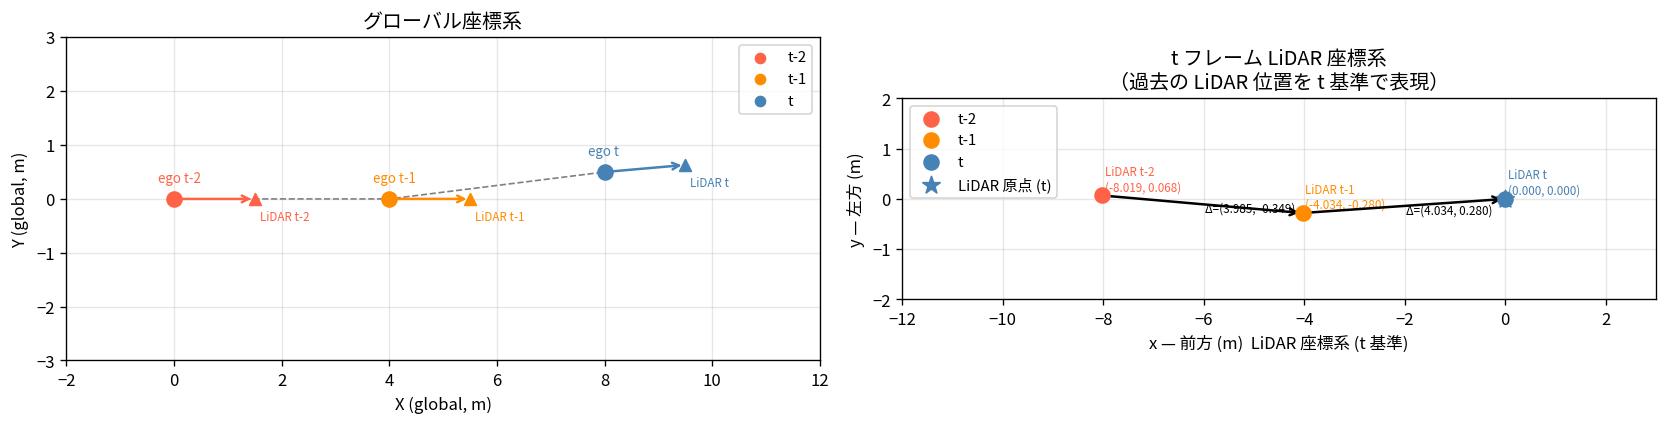

In [4]:
# 3 フレームのシナリオ：直進 → 左折開始
frames = [
    {"label": "t-2", "tx": 0.0,  "ty": 0.0,  "yaw": np.radians(0)},
    {"label": "t-1", "tx": 4.0,  "ty": 0.0,  "yaw": np.radians(0)},
    {"label": "t",   "tx": 8.0,  "ty": 0.5,  "yaw": np.radians(5)},
]

# ego_from_lidar（共通: LiDAR は ego 前方 1.5m）
T_ego_from_lidar = rigid(1.5, 0.0, 0.0, tz=1.84)

# 各フレームの T_global_from_lidar と LiDAR グローバル位置
for f in frames:
    T_gfe = rigid(f['tx'], f['ty'], f['yaw'])
    T_gfl = T_gfe @ T_ego_from_lidar
    f['T_global_from_ego']   = T_gfe
    f['T_global_from_lidar'] = T_gfl
    f['lidar_pos_global']    = T_gfl[:3, 3].copy()

# 現フレーム (t) の lidar_from_global
T_lidar_from_global_t = np.linalg.inv(frames[2]['T_global_from_lidar'])

# 各フレームの LiDAR グローバル位置を t フレームの LiDAR 座標に変換
print("=" * 60)
print("LiDAR グローバル位置 → t フレームの LiDAR 座標系")
print("=" * 60)
pts_lidar = []
for f in frames:
    p_global = f['lidar_pos_global']
    p_lidar  = transform_point(T_lidar_from_global_t, p_global)[:2]
    pts_lidar.append(p_lidar)
    print(f"  {f['label']}: global=({p_global[0]:.3f}, {p_global[1]:.3f}) "
          f"→ LiDAR=({p_lidar[0]:.4f}, {p_lidar[1]:.4f})")

# per-step diff
diffs = np.array([pts_lidar[1] - pts_lidar[0],
                  pts_lidar[2] - pts_lidar[1]])
print(f"\ngt_ego_his_trajs:")
print(f"  step1 (t-2→t-1): dx={diffs[0,0]:.4f}m, dy={diffs[0,1]:.4f}m")
print(f"  step2 (t-1→ t ): dx={diffs[1,0]:.4f}m, dy={diffs[1,1]:.4f}m")
print(f"  shape: {diffs.shape}")

# --- 可視化 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_frame = ['tomato', 'darkorange', 'steelblue']

# 左図: グローバル座標系
ax = axes[0]
for f, col in zip(frames, colors_frame):
    ex, ey = f['tx'], f['ty']
    lx, ly = f['lidar_pos_global'][0], f['lidar_pos_global'][1]
    yaw = f['yaw']
    # ego 位置
    ax.scatter([ex], [ey], s=80, color=col, zorder=5)
    ax.text(ex - 0.3, ey + 0.3, f"ego {f['label']}", fontsize=8, color=col)
    # LiDAR 位置
    ax.scatter([lx], [ly], s=50, marker='^', color=col, zorder=5)
    ax.text(lx + 0.1, ly - 0.4, f"LiDAR {f['label']}", fontsize=7, color=col)
    # 進行方向矢印
    ax.annotate('', xy=(ex + 1.5*np.cos(yaw), ey + 1.5*np.sin(yaw)),
                xytext=(ex, ey),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.5))

# ego 軌跡
exs = [f['tx'] for f in frames]
eys = [f['ty'] for f in frames]
ax.plot(exs, eys, '--', color='gray', linewidth=1)
ax.set_aspect('equal')
ax.set_xlim(-2, 12)
ax.set_ylim(-3, 3)
ax.set_xlabel('X (global, m)')
ax.set_ylabel('Y (global, m)')
ax.set_title('グローバル座標系')
ax.grid(True, alpha=0.3)
for col, lbl in zip(colors_frame, ['t-2', 't-1', 't']):
    ax.scatter([], [], color=col, label=lbl)
ax.legend(fontsize=9)

# 右図: t フレーム LiDAR 座標系
ax = axes[1]
for (px, py), col, f in zip(pts_lidar, colors_frame, frames):
    ax.scatter([px], [py], s=80, color=col, zorder=5, label=f['label'])
    ax.text(px + 0.05, py + 0.1, f"LiDAR {f['label']}\n({px:.3f}, {py:.3f})",
            fontsize=7, color=col)

# diff 矢印
for i in range(2):
    x0, y0 = pts_lidar[i]
    x1, y1 = pts_lidar[i+1]
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    mx, my = (x0+x1)/2, (y0+y1)/2
    ax.text(mx + 0.05, my - 0.15,
            f"Δ=({x1-x0:.3f}, {y1-y0:.3f})", fontsize=7)

ax.scatter([0], [0], s=120, color='steelblue', marker='*', zorder=6, label='LiDAR 原点 (t)')
ax.set_aspect('equal')
ax.set_xlim(-12, 3)
ax.set_ylim(-2, 2)
ax.set_xlabel('x — 前方 (m)  LiDAR 座標系 (t 基準)')
ax.set_ylabel('y — 左方 (m)')
ax.set_title('t フレーム LiDAR 座標系\n（過去の LiDAR 位置を t 基準で表現）')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. 各座標系を並べて比較

同一のシーン（障害物 + 自車）を 3 つの座標系で表現し、変換の「見え方」の違いを確認する。

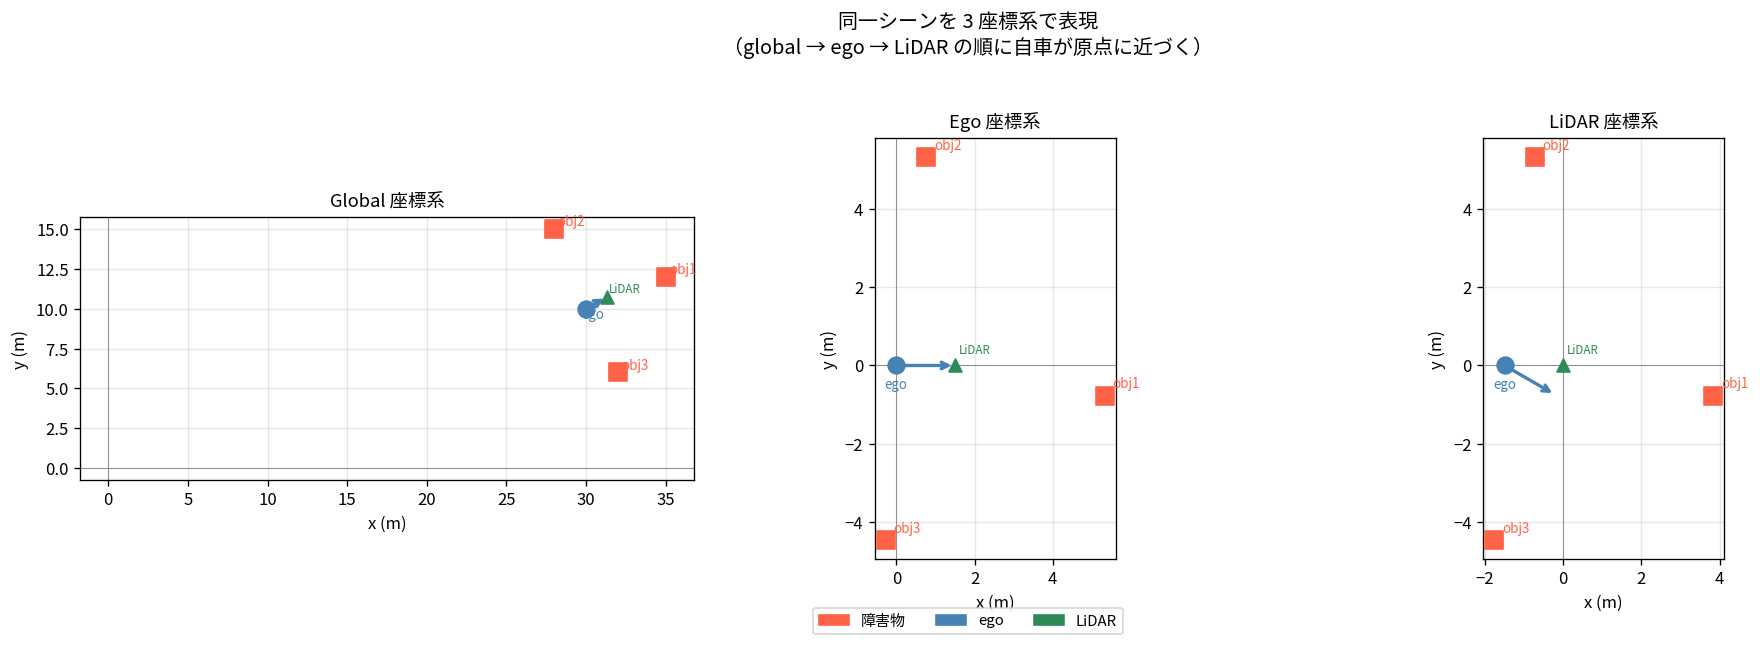

In [5]:
# シーン設定: 自車 yaw=30°, 障害物 3 つ
ego_tx, ego_ty, ego_yaw = 30.0, 10.0, np.radians(30)
T_gfe = rigid(ego_tx, ego_ty, ego_yaw)
T_efl = rigid(1.5, 0.0, 0.0, tz=0.0)   # z 無視で 2D
T_gfl = T_gfe @ T_efl

T_ego_from_global  = np.linalg.inv(T_gfe)
T_lidar_from_global = np.linalg.inv(T_gfl)

# 障害物のグローバル位置
objects_global = np.array([
    [35.0, 12.0, 0.0],   # 前方右
    [28.0, 15.0, 0.0],   # 左前
    [32.0,  6.0, 0.0],   # 右
])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Global 座標系', 'Ego 座標系', 'LiDAR 座標系']
transforms = [np.eye(4), T_ego_from_global, T_lidar_from_global]
ego_in_coord = [
    np.array([ego_tx, ego_ty]),                               # global での ego
    np.array([0.0, 0.0]),                                     # ego 座標系では原点
    transform_point(T_lidar_from_global, np.array([ego_tx, ego_ty, 0.0]))[:2],
]
lidar_in_coord = [
    T_gfl[:2, 3],                                             # global での LiDAR
    transform_point(T_ego_from_global, T_gfl[:3, 3])[:2],    # ego 座標系での LiDAR
    np.array([0.0, 0.0]),                                     # LiDAR 座標系では原点
]

for ax, title, T, epos, lpos in zip(axes, titles, transforms, ego_in_coord, lidar_in_coord):
    # 障害物をプロット
    for i, obj_g in enumerate(objects_global):
        obj = transform_point(T, obj_g)
        ax.scatter([obj[0]], [obj[1]], s=120, color='tomato',
                   marker='s', zorder=5)
        ax.text(obj[0] + 0.2, obj[1] + 0.2, f'obj{i+1}', fontsize=8, color='tomato')

    # 自車位置
    yaw_in_coord = ego_yaw if title == 'Global 座標系' else (0.0 if 'Ego' in title else -ego_yaw)
    ax.scatter([epos[0]], [epos[1]], s=100, color='steelblue', zorder=6)
    ax.annotate('', xy=(epos[0]+1.5*np.cos(yaw_in_coord), epos[1]+1.5*np.sin(yaw_in_coord)),
                xytext=(epos[0], epos[1]),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
    ax.text(epos[0]-0.3, epos[1]-0.6, 'ego', fontsize=8, color='steelblue')

    # LiDAR 位置
    ax.scatter([lpos[0]], [lpos[1]], s=60, color='seagreen', marker='^', zorder=6)
    ax.text(lpos[0]+0.1, lpos[1]+0.3, 'LiDAR', fontsize=7, color='seagreen')

    # 軸
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.grid(True, alpha=0.3)

obj_patch = mpatches.Patch(color='tomato',    label='障害物')
ego_patch = mpatches.Patch(color='steelblue', label='ego')
lid_patch = mpatches.Patch(color='seagreen',  label='LiDAR')
fig.legend(handles=[obj_patch, ego_patch, lid_patch],
           loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('同一シーンを 3 座標系で表現\n（global → ego → LiDAR の順に自車が原点に近づく）',
             y=1.03, fontsize=12)
plt.tight_layout()
plt.show()